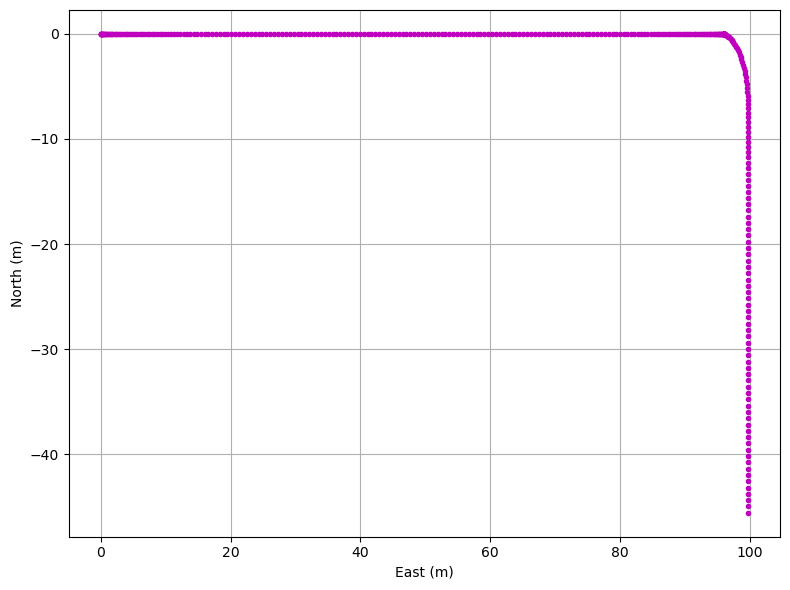

In [96]:
"""
MAE 6760 Model Based Estimation
Cornell University
M Campbell

Solution
Homework #4
Problem #1: Extended Kalman Filter (EKF)
    planar pose of a car with IMU biases
    uses the following Python functions:
        plot_estimator.py
        calculate_ellipse.py
"""

import numpy as np
import matplotlib.pyplot as plt

from plot_estimator import plot_estimator
from calculate_ellipse import calculate_ellipse

# -------------------------------------------------
# User input parameters
# -------------------------------------------------
scenario_type = "baseline"
#scenario_type = "swervy"

np.random.seed(100)


# ------------------------------------------------------------
# Control input generator
# ------------------------------------------------------------

def get_controlinputs(scenario_type):

    if scenario_type == "baseline":

        Uacc = np.concatenate([
            np.ones(60),
            np.zeros(100),
            -np.ones(60),
            np.zeros(20),
            np.ones(60),
            np.zeros(50)
        ])

        Uomega = np.concatenate([
            np.zeros(240),
            -np.ones(40)*np.pi/2/4,
            np.zeros(70)
        ])

    elif scenario_type == "swervy":

        Uacc = np.concatenate([
            np.ones(60),
            np.zeros(230),
            -np.ones(60)
        ])

        Uomega = np.concatenate([
            np.zeros(60),
            np.ones(10)*np.pi/2/2,
            -np.ones(20)*np.pi/2/2,
            np.ones(20)*np.pi/2/2,
            -np.ones(20)*np.pi/2/2,
            np.ones(20)*np.pi/2/2,
            -np.ones(10)*np.pi/2/2,
            np.zeros(30),
            np.ones(10)*np.pi/2/2,
            -np.ones(20)*np.pi/2/2,
            np.ones(20)*np.pi/2/2,
            -np.ones(20)*np.pi/2/2,
            np.ones(20)*np.pi/2/2,
            -np.ones(10)*np.pi/2/2,
            np.zeros(60)
        ])

    else:
        raise ValueError("unknown scenario")

    return Uacc, Uomega

# ------------------------------------------------------------
# Simulate system
# ------------------------------------------------------------

Uacc, Uomega = get_controlinputs(scenario_type)

dt = 0.1
nt = len(Uacc)
t = np.arange(0, dt*nt, dt)

nx = 4
x_true = np.zeros((nx, nt))

for k in range(nt-1):

    Vk = x_true[2,k]
    Tk = x_true[3,k]

    x_true[:,k+1] = x_true[:,k] + dt*np.array([
        Vk*np.cos(Tk),
        Vk*np.sin(Tk),
        Uacc[k],
        Uomega[k]
    ])

# ---------------------------------------------------------
# Plot Birds-eye view of true trajectory
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
plt.plot(x_true[0,:], x_true[1,:], 'm.', linewidth=3)
plt.grid(True)
plt.xlabel("East (m)")
plt.ylabel("North (m)")
plt.tight_layout()
plt.show()


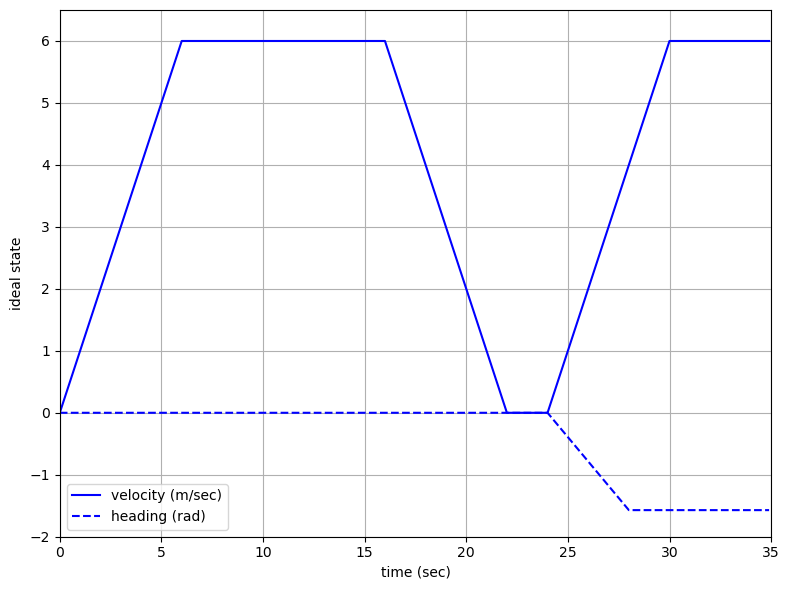

In [97]:
# ---------------------------------------------------------
# Plot true velocity and heading
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
plt.plot(t, x_true[2,:], 'b-')
plt.plot(t, x_true[3,:], 'b--')
plt.xlabel("time (sec)")
plt.ylabel("ideal state")
plt.legend(["velocity (m/sec)", "heading (rad)"], loc="lower left")
plt.axis([0, nt*dt, -2, 6.5])
plt.grid(True)
plt.tight_layout()



In [98]:
# ------------------------------------------------------------
# Generate noise and measurements
# ------------------------------------------------------------

bias_acc = 0.1
bias_rg  = -0.025

x_true = np.vstack((x_true,
                    bias_acc*np.ones(nt),
                    bias_rg*np.ones(nt)))

nx = 6

Q = np.diag([0.1**2, 0.04**2])
w = np.linalg.cholesky(Q) @ np.random.randn(2,nt)

Zacc = Uacc + bias_acc + w[0,:]
Zrg  = Uomega + bias_rg + w[1,:]

nz = 2
R = np.eye(nz)

v = np.linalg.cholesky(R) @ np.random.randn(nz,nt)
z = x_true[0:2,:] + v

H = np.hstack((np.eye(2), np.zeros((2,4))))

In [99]:
# ------------------------------------------------------------
# System model functions
# ------------------------------------------------------------

def predict_state_carposebias(Xk, U, dt):

    ##YOUR CODE HERE
    x,y,V,th,ba,bw = Xk
    uacc = U[0]
    urot = U[1]
    Xkp1 = Xk + dt*np.array([V*np.cos(th), V*np.sin(th), uacc-ba, urot-bw,0,0])

    return Xkp1


def getFG_carposebias(X, dt):
    x,y,V,th,ba,bw = X
    F = np.array([[1,0,dt*np.cos(th),-dt*V*np.sin(th),0,0],[0,1, dt*np.sin(th), dt*V*np.cos(th),0,0],[0,0,1,0,-dt,0],[0,0,0,1,0,-dt],[0,0,0,0,1,0],[0,0,0,0,0,1]])
    G = np.array([[0,0],[0,0],[dt,0],[0,dt],[0,0],[0,0]])
    return F, G

In [100]:
# ------------------------------------------------------------
# Extended Kalman Filter (EKF)
# ------------------------------------------------------------

#initialize

x0 = np.array([0, 0, 0, 0, 0, 0])
xhatk_k = x0

P0 = np.diag([2**2, 2**2, 1**2, 0.1**2, 0.2**2, 0.05**2])
Pk_k = P0

# preallocate 

xhatu = np.zeros((nx, nt))
xhatu[:, 0] = x0

Pu = np.zeros((nx, nx, nt))
Pu[:, :, 0] = P0

I = np.eye(nx)

for i in range(nt-1):
    #predict
    F,G = getFG_carposebias(xhatk_k, dt)
    U = np.array([Zacc[i], Zrg[i]])
    xhatk1_k = predict_state_carposebias(xhatk_k, U, dt)
    Pk1_k = F@Pk_k@F.T + G@Q@G.T

    #Kalman Gain
    Kk1 = Pk1_k@ H.T @ np.linalg.inv(H @ Pk1_k @ H.T + R)

    #update

    xhatk1_k1 = xhatk1_k + Kk1@(z.T[i+1] - H@xhatk1_k)
    Pk1_k1 = (I - Kk1@H)@Pk1_k@(I - Kk1@H).T + Kk1@R@Kk1.T

    # relabel to iterate
    Pk_k = Pk1_k1
    xhatk_k = xhatk1_k1

    xhatu[:,i+1] = xhatk_k
    Pu[:,:,i+1] = Pk_k

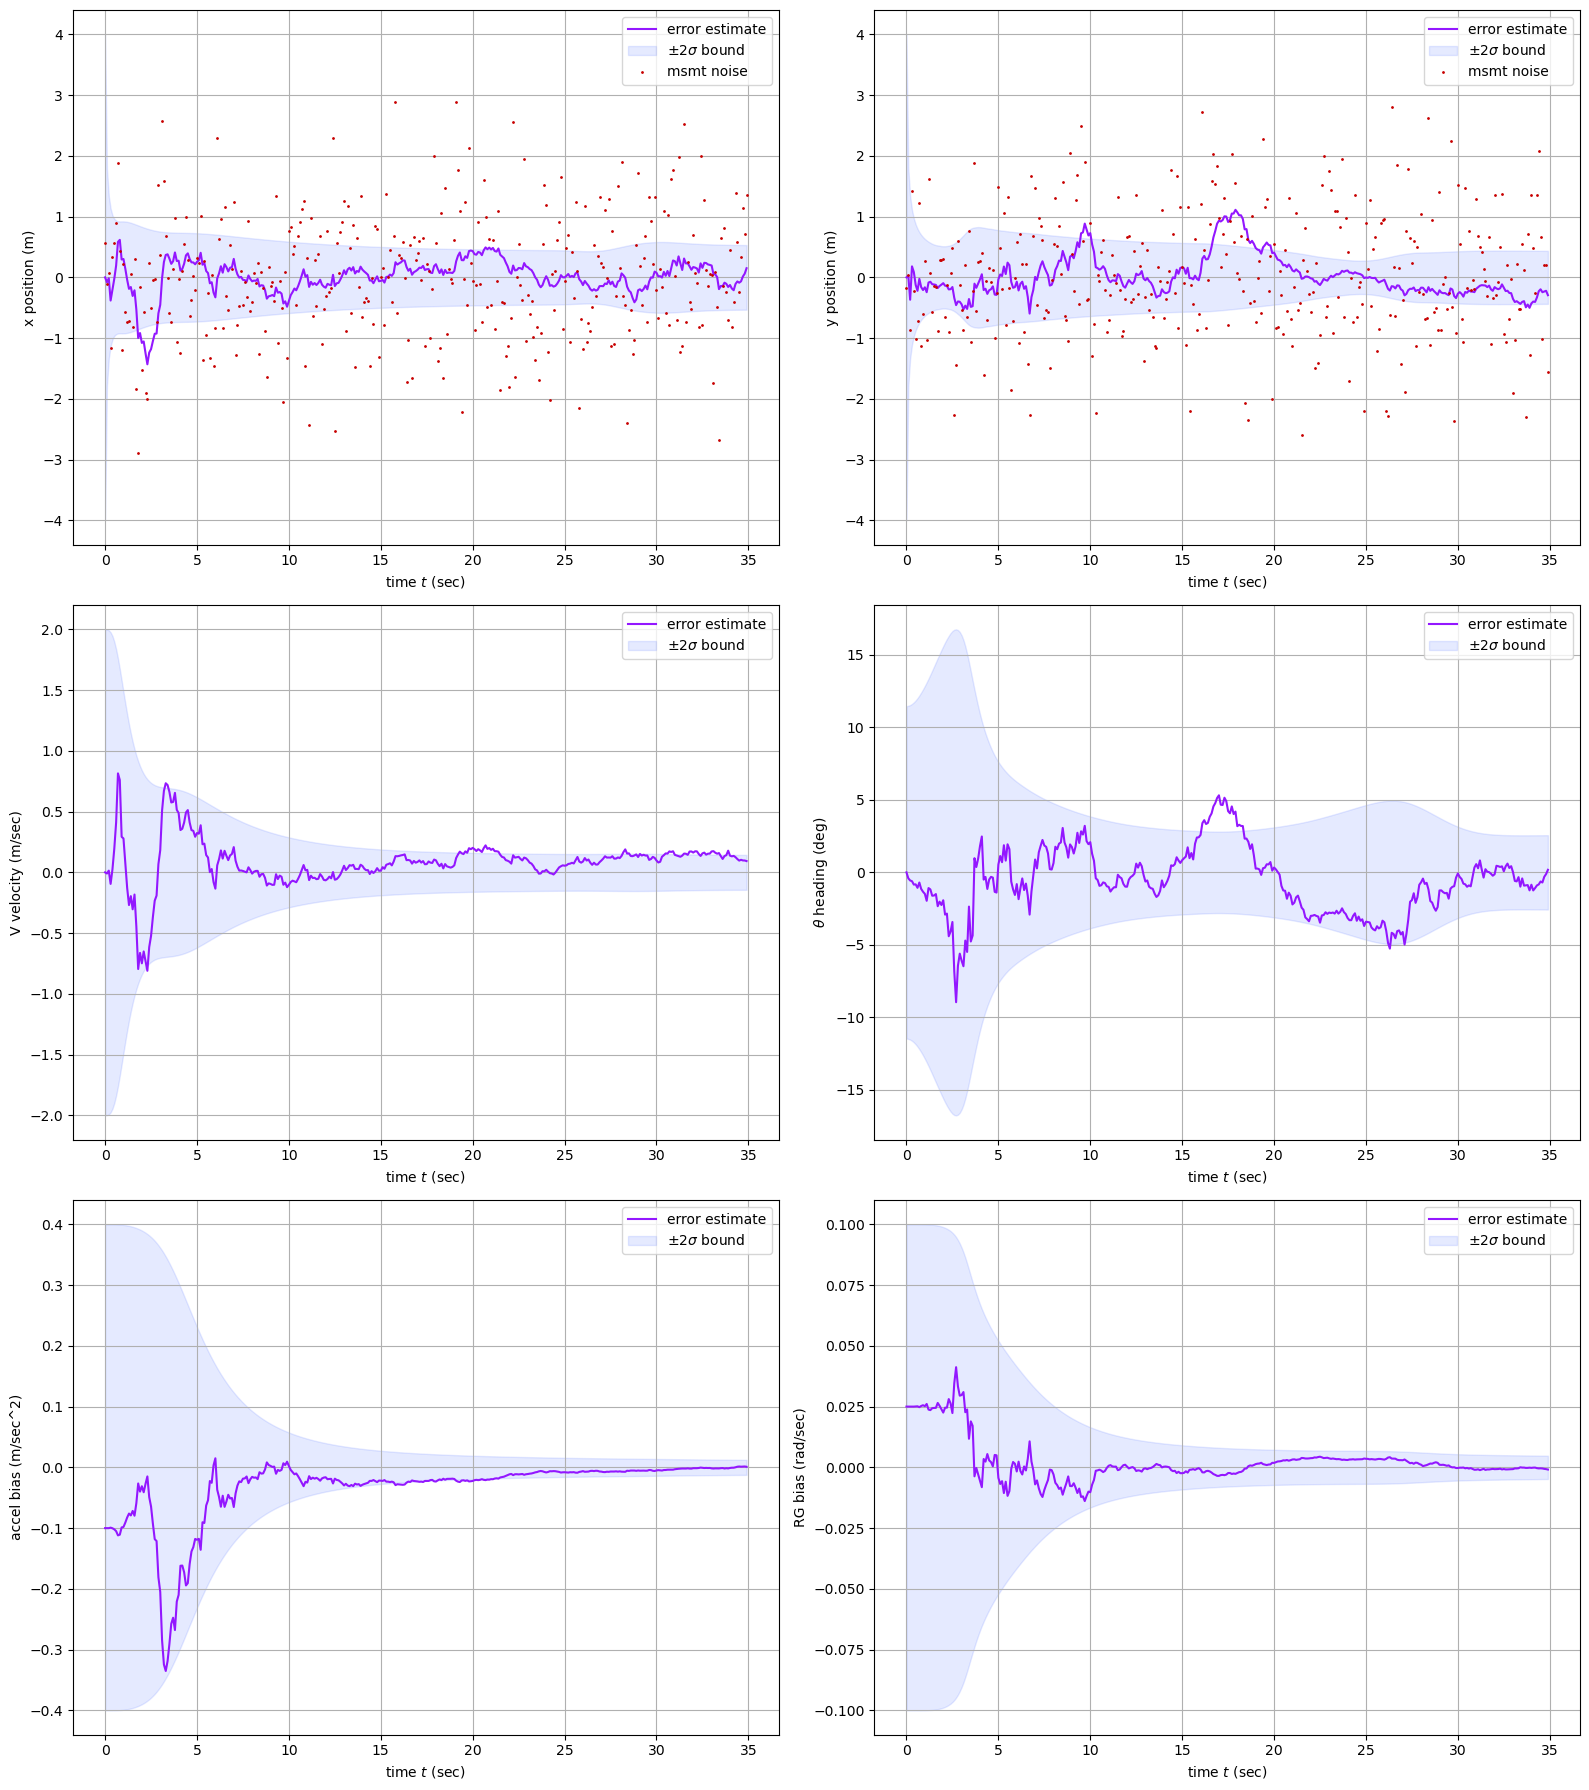

In [109]:
# ---------------------------------------------------------
# Estimator plots
# ---------------------------------------------------------


fig, ax = plt.subplots(3,2, figsize=(16,6*3))
ax = np.ravel(ax)
plot_estimator(t, xhatu[0,:], Pu[0,0,:], x_true[0,:],
               "error", z[0,:], ax=ax[0])
ax[0].set_ylabel("x position (m)")
plot_estimator(t, xhatu[1,:], Pu[1,1,:], x_true[1,:],
               "error", z[1,:], ax=ax[1])
ax[1].set_ylabel("y position (m)")
plt.tight_layout()

#fig, ax = plt.subplots(1,2, figsize=(16,6))
plot_estimator(t, xhatu[2,:], Pu[2,2,:], x_true[2,:],
               "error", ax=ax[2])
ax[2].set_ylabel("V velocity (m/sec)")
thC = 180/np.pi
plot_estimator(t, xhatu[3,:]*thC, Pu[3,3,:]*thC**2, x_true[3,:]*thC,
               "error", ax=ax[3])
ax[3].set_ylabel(r"$\theta$ heading (deg)")
plt.tight_layout()

#fig, ax = plt.subplots(1,2, figsize=(16,6))
plot_estimator(t, xhatu[4,:], Pu[4,4,:], x_true[4,:],
               "error", ax=ax[4])
ax[4].set_ylabel("accel bias (m/sec^2)")
plot_estimator(t, xhatu[5,:], Pu[5,5,:], x_true[5,:],
               "error", ax=ax[5])
ax[5].set_ylabel("RG bias (rad/sec)")
plt.tight_layout()



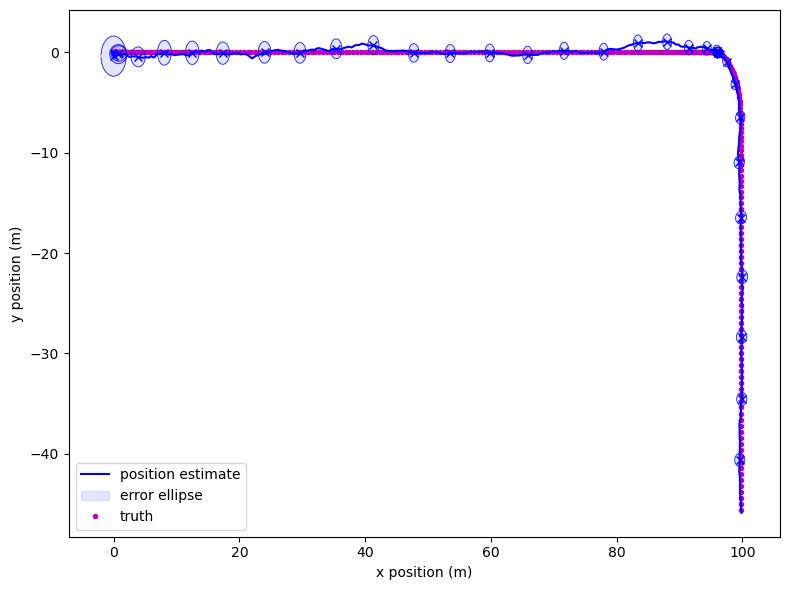

In [102]:
# ---------------------------------------------------------
# Trajectory with uncertainty ellipses
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

pt, = plt.plot(x_true[0,:], x_true[1,:], 'm.')
ph, = plt.plot(xhatu[0,:], xhatu[1,:], 'b-')

iell = np.concatenate(([2], np.arange(10, nt, 10)))

patch_handles = []

for ii in iell:

    Xe, Ye, _, _, _ = calculate_ellipse(
        xhatu[0:2,ii],
        Pu[0:2,0:2,ii],
        3, 50
    )

    plt.plot(xhatu[0,ii], xhatu[1,ii], 'bx')

    ne = len(Xe)

    x1 = np.concatenate((Xe[int(ne/2):], Xe[:int(ne/2)]))
    y1 = np.concatenate((Ye[int(ne/2):], Ye[:int(ne/2)]))

    plt.plot(x1, y1, 'b-', label='1-sigma ellipse',linewidth=0.5)
    p = plt.fill(x1, y1, alpha=0.1, color='b')
    patch_handles.append(p[0])

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")

plt.legend([ph, patch_handles[0], pt],
           ["position estimate", "error ellipse", "truth"],
           loc="lower left")

plt.tight_layout()

plt.show()